# Malaysia Fish Landings & Economic Indicators
## Phase 5+6 — Baseline Linear Regression

**Purpose:** Quantify the **contemporaneous** association between fish landings  
and each economic variable using OLS regression.

This is the **descriptive baseline** before the causal VAR analysis.  
It answers: *"Holding COVID and seasonality constant, how much does a 1% increase  
in fish landings associate with changes in fishing GDP, food CPI, and food exports?"*

**Important framing:** This is NOT causal — it is associational.  
Causality is established in Phase 7 (Granger/VAR).  
This section mirrors the approach in Hamid-Mosaku et al. (2017) and Marshak & Link (2021).

**Variables:** All as Δln (first differences), consistent with Phase 3 decisions.

In [1]:
# Cell P5.1 — Setup, load, prepare
!pip install pandas numpy matplotlib scipy statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.labelsize': 9, 'axes.grid': True, 'grid.alpha': 0.3
})
PALETTE = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0']
OUT  = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"
BASE = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"

df = pd.read_csv(BASE + "master_dataset_analysis.csv")
df['quarter'] = pd.PeriodIndex(df['quarter_str'], freq='Q')
df = df.sort_values('quarter').reset_index(drop=True)

# Working dataset: drop first row (NaN from differencing)
work = df[['dln_landings','dln_gdp_fishing','dln_cpi_food','dln_food_exports',
           'covid','Q2','Q3','Q4','wind_speed','quarter_str']].dropna().copy()
work = work.reset_index(drop=True)

print(f"Working obs: {len(work)} | Period: {work.quarter_str.iloc[0]} to {work.quarter_str.iloc[-1]}")
print(f"Variables: {[c for c in work.columns if c not in ['quarter_str']]}")

Mounted at /content/drive
Working obs: 23 | Period: 2018Q2 to 2023Q4
Variables: ['dln_landings', 'dln_gdp_fishing', 'dln_cpi_food', 'dln_food_exports', 'covid', 'Q2', 'Q3', 'Q4', 'wind_speed']


---
## Model Specification

Three OLS models — one for each economic outcome:

- **Model 1:** Δln(Fishing GDP) ~ Δln(Landings) + COVID + Q2 + Q3 + Q4
- **Model 2:** Δln(Food CPI) ~ Δln(Landings) + COVID + Q2 + Q3 + Q4  
- **Model 3:** Δln(Food Exports) ~ Δln(Landings) + COVID + Q2 + Q3 + Q4

Controls included: COVID structural break dummy, seasonal dummies (Q1=base).  
Wind speed excluded from baseline (added in robustness check).

In [2]:
# Cell P5.2 — Run all 3 OLS models and produce Table 6 (paper)

outcomes = [
    ('dln_gdp_fishing',  'Δln(Fishing GDP)',   PALETTE[1]),
    ('dln_cpi_food',     'Δln(Food CPI)',       PALETTE[2]),
    ('dln_food_exports', 'Δln(Food Exports)',   PALETTE[3]),
]

models      = {}
model_stats = []

for dep_var, dep_label, color in outcomes:
    formula = f"{dep_var} ~ dln_landings + covid + Q2 + Q3 + Q4"
    model   = smf.ols(formula, data=work).fit(cov_type='HC3')  # HC3 = heteroscedasticity-robust SE
    models[dep_var] = model

    # Diagnostic tests
    resid = model.resid
    jb_stat, jb_p, _, _ = jarque_bera(resid)
    lb_result = acorr_ljungbox(resid, lags=[4], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, model.model.exog)

    model_stats.append({
        'Outcome':       dep_label,
        'β_landings':    round(model.params['dln_landings'], 4),
        'SE':            round(model.bse['dln_landings'], 4),
        'p-value':       round(model.pvalues['dln_landings'], 4),
        'Sig':           '***' if model.pvalues['dln_landings']<0.01
                         else '**' if model.pvalues['dln_landings']<0.05
                         else '*'  if model.pvalues['dln_landings']<0.10
                         else '',
        'R²':            round(model.rsquared, 4),
        'Adj. R²':       round(model.rsquared_adj, 4),
        'N':             int(model.nobs),
        'JB p':          round(jb_p, 3),
        'LB(4) p':       round(lb_p, 3),
        'BP p':          round(bp_p, 3),
    })

results_df = pd.DataFrame(model_stats).set_index('Outcome')

print("=" * 90)
print("Table 6: Baseline OLS Regression Results")
print("Dependent variables regressed on Δln(Fish Landings) + controls")
print("Robust standard errors (HC3). Controls: COVID dummy, Q2, Q3, Q4.")
print("=" * 90)
print(results_df[['β_landings','SE','p-value','Sig','R²','Adj. R²','N']].to_string())
print()
print("Diagnostic tests (p-values — H₀: no violation):")
print(results_df[['JB p','LB(4) p','BP p']].to_string())
print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
print("JB = Jarque-Bera (normality) | LB(4) = Ljung-Box lag 4 (no autocorrelation) | BP = Breusch-Pagan (homoscedasticity)")
print()
print("NOTE: Low R² is expected and consistent with literature.")
print("Contemporaneous OLS captures SAME-PERIOD association only.")
print("Temporal precedence (causality) is tested in Phase 7 (Granger/VAR).")

Table 6: Baseline OLS Regression Results
Dependent variables regressed on Δln(Fish Landings) + controls
Robust standard errors (HC3). Controls: COVID dummy, Q2, Q3, Q4.
                   β_landings      SE  p-value Sig      R²  Adj. R²   N
Outcome                                                                
Δln(Fishing GDP)       0.2060  0.1797   0.2515      0.9665   0.9566  23
Δln(Food CPI)         -0.0398  0.0350   0.2560      0.2757   0.0627  23
Δln(Food Exports)      0.0645  0.3264   0.8434      0.6694   0.5722  23

Diagnostic tests (p-values — H₀: no violation):
                    JB p  LB(4) p   BP p
Outcome                                 
Δln(Fishing GDP)   0.589    0.294  0.604
Δln(Food CPI)      0.759    0.003  0.456
Δln(Food Exports)  0.111    0.272  0.033

Significance: *** p<0.01  ** p<0.05  * p<0.10
JB = Jarque-Bera (normality) | LB(4) = Ljung-Box lag 4 (no autocorrelation) | BP = Breusch-Pagan (homoscedasticity)

NOTE: Low R² is expected and consistent with literatu

In [3]:
# Cell P5.3 — Full regression output for all 3 models (appendix table)

for dep_var, dep_label, _ in outcomes:
    m = models[dep_var]
    print(f"{'='*65}")
    print(f"Model: Δln({dep_label.replace('Δln(','').replace(')','')})")
    print(f"{'='*65}")
    coef_table = pd.DataFrame({
        'Coef':  m.params.round(5),
        'SE':    m.bse.round(5),
        't':     m.tvalues.round(3),
        'p':     m.pvalues.round(4),
        'Sig':   [('***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')))
                  for p in m.pvalues],
        '[0.025': m.conf_int()[0].round(5),
        '0.975]': m.conf_int()[1].round(5),
    })
    print(coef_table.to_string())
    print(f"R² = {m.rsquared:.4f} | Adj. R² = {m.rsquared_adj:.4f} | F-stat p = {m.f_pvalue:.4f}")
    print()

Model: Δln(Fishing GDP)
                 Coef       SE      t       p  Sig   [0.025   0.975]
Intercept    -0.03672  0.02637 -1.393  0.1637      -0.08840  0.01496
dln_landings  0.20604  0.17967  1.147  0.2515      -0.14611  0.55819
covid        -0.00228  0.01619 -0.141  0.8881      -0.03400  0.02945
Q2           -0.00644  0.05175 -0.124  0.9010      -0.10786  0.09498
Q3            0.27698  0.02853  9.707  0.0000  ***  0.22106  0.33291
Q4           -0.12608  0.02977 -4.236  0.0000  *** -0.18442 -0.06774
R² = 0.9665 | Adj. R² = 0.9566 | F-stat p = 0.0000

Model: Δln(Food CPI)
                 Coef       SE      t       p Sig   [0.025   0.975]
Intercept     0.00903  0.00422  2.141  0.0323  **  0.00076  0.01729
dln_landings -0.03976  0.03500 -1.136  0.2560     -0.10837  0.02884
covid        -0.00355  0.00304 -1.168  0.2428     -0.00951  0.00241
Q2            0.00098  0.00999  0.099  0.9215     -0.01859  0.02056
Q3           -0.00018  0.00658 -0.027  0.9784     -0.01307  0.01271
Q4          

---
## Figure 10: Coefficient Plot (for paper)

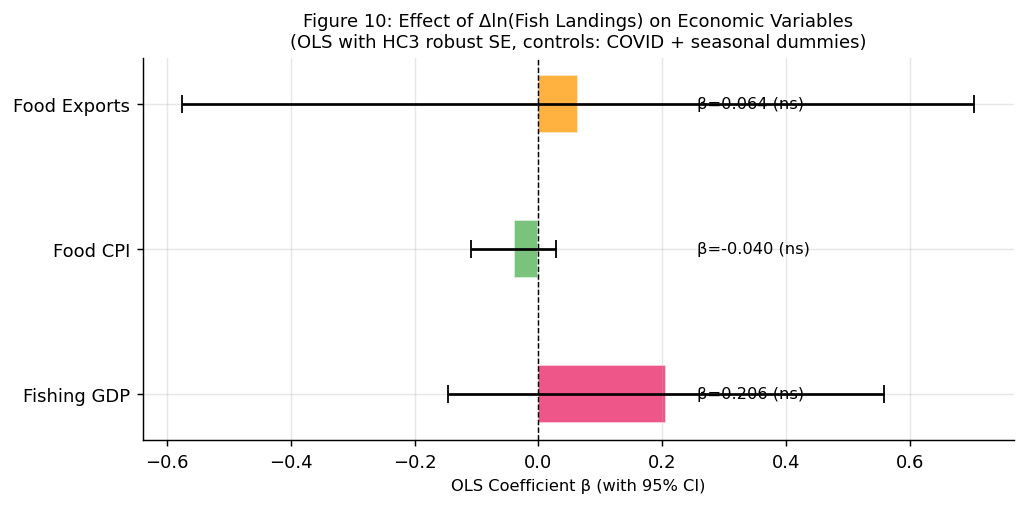

Saved: fig10_coef_plot.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Cell P5.4 — Figure 10: Coefficient plot with 95% CI for dln_landings across all models
# Clean visual summary of the regression results — standard in econometrics papers

fig, ax = plt.subplots(figsize=(8, 4))

model_names = [dep_label for _, dep_label, _ in outcomes]
colors_plot  = [color for _, _, color in outcomes]
coefs = [models[dv].params['dln_landings'] for dv, _, _ in outcomes]
cis   = [(models[dv].conf_int().loc['dln_landings', 0],
          models[dv].conf_int().loc['dln_landings', 1])
         for dv, _, _ in outcomes]
pvals = [models[dv].pvalues['dln_landings'] for dv, _, _ in outcomes]

y_pos = range(len(outcomes))
for i, (coef, ci, color, p) in enumerate(zip(coefs, cis, colors_plot, pvals)):
    ax.barh(i, coef, color=color, alpha=0.75, height=0.4, edgecolor='white')
    ax.errorbar(coef, i, xerr=[[coef - ci[0]], [ci[1] - coef]],
                fmt='none', color='black', capsize=5, linewidth=1.5)
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else 'ns'))
    ax.text(max(coefs)+0.05, i, f'β={coef:.3f} ({sig})',
            va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(list(y_pos))
ax.set_yticklabels([l.replace('Δln(','').replace(')','') for l in model_names])
ax.set_xlabel('OLS Coefficient β (with 95% CI)')
ax.set_title('Figure 10: Effect of Δln(Fish Landings) on Economic Variables\n'
             '(OLS with HC3 robust SE, controls: COVID + seasonal dummies)',
             fontsize=10)

plt.tight_layout()
plt.savefig(OUT + "fig10_coef_plot.png", bbox_inches='tight')
plt.show()
print("Saved: fig10_coef_plot.png")

---
## Residual Diagnostics (Figure 11)

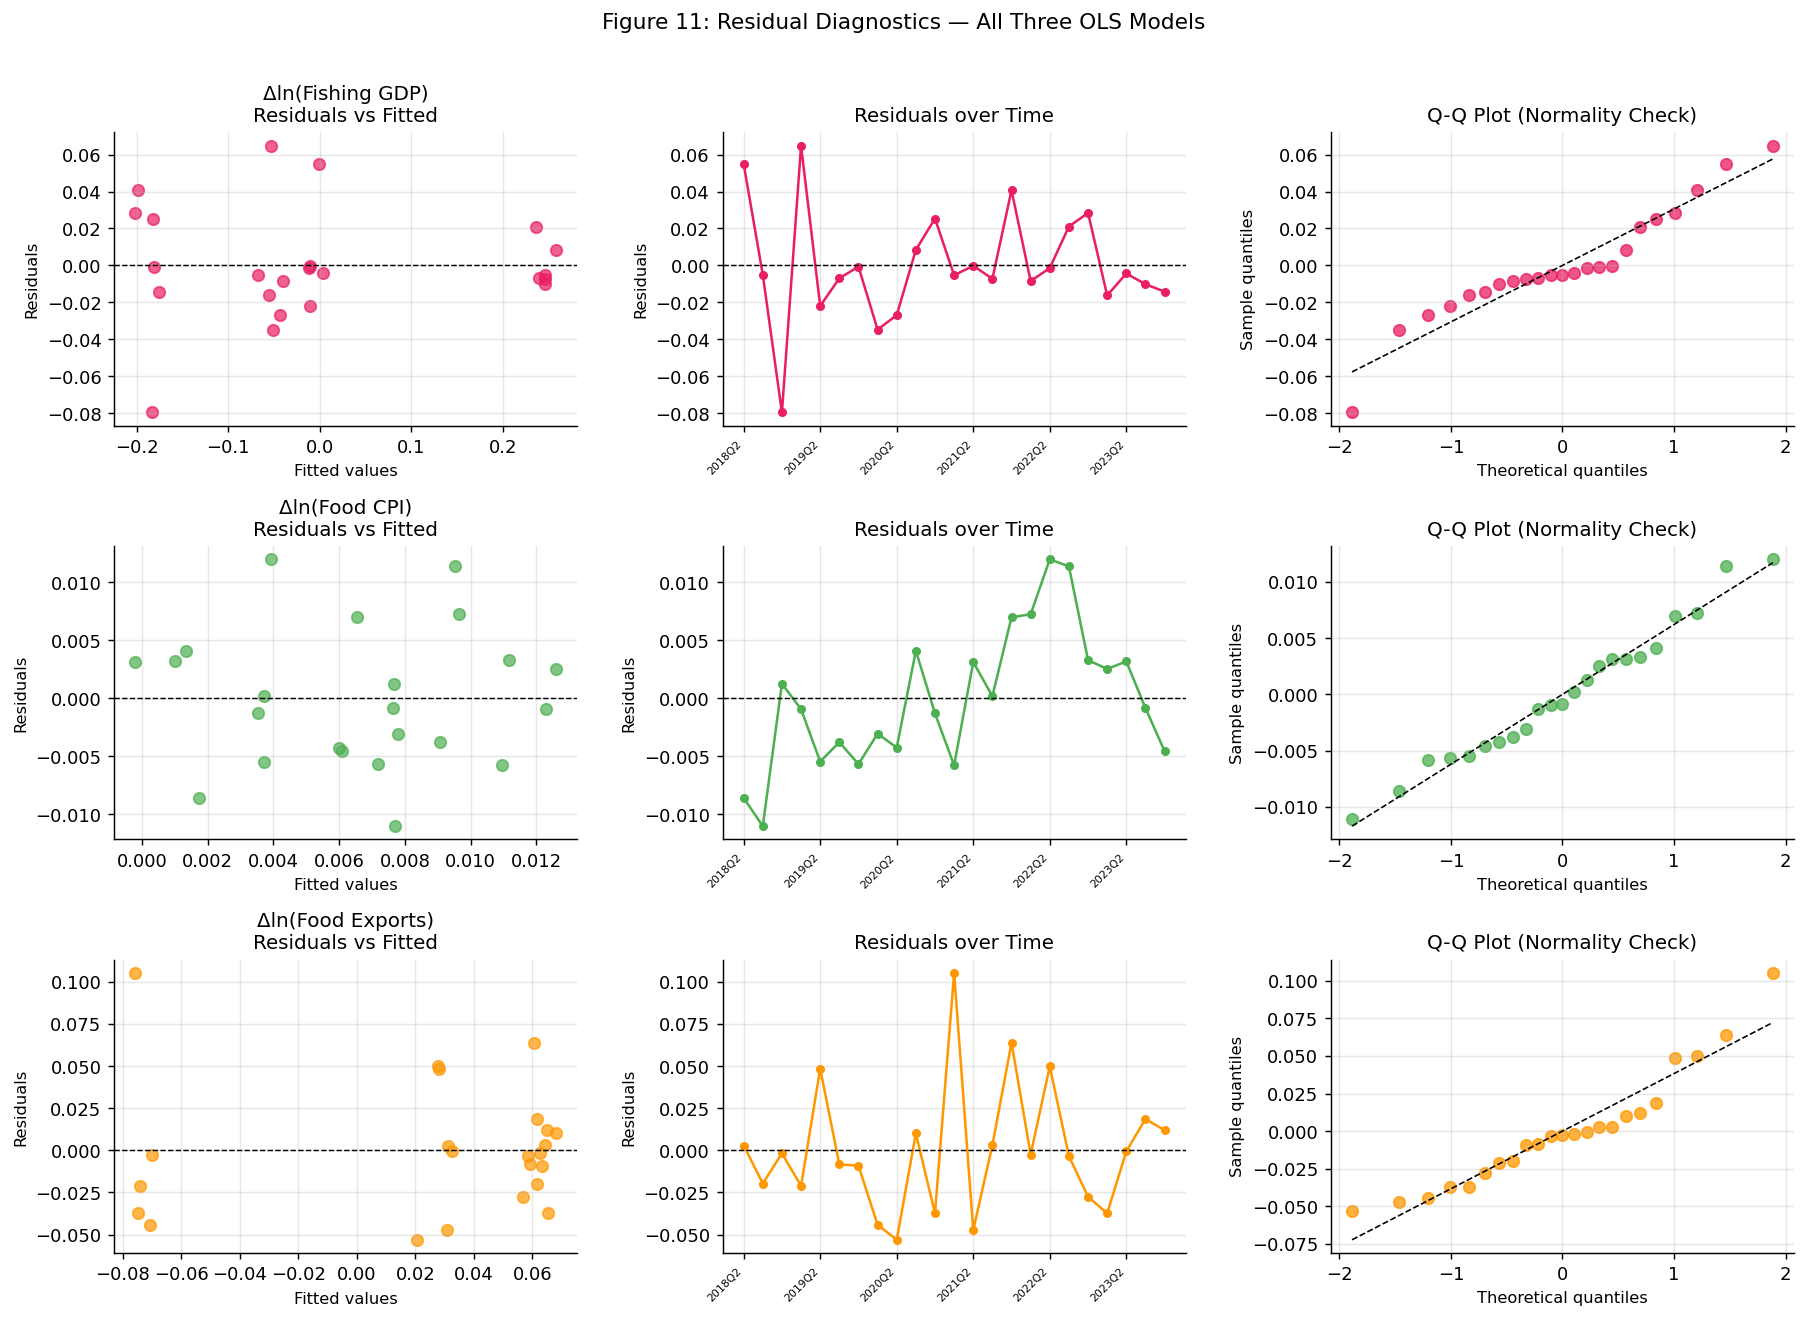

Saved: fig11_residual_diagnostics.png


In [5]:
# Cell P5.5 — Figure 11: Residual plots for all 3 models
# Required for model validity — checks OLS assumptions

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for row_i, (dep_var, dep_label, color) in enumerate(outcomes):
    m     = models[dep_var]
    resid = m.resid
    fitted= m.fittedvalues
    q_labels = work['quarter_str'].values

    # Residuals vs Fitted
    axes[row_i, 0].scatter(fitted, resid, color=color, alpha=0.7, s=40)
    axes[row_i, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[row_i, 0].set_xlabel('Fitted values')
    axes[row_i, 0].set_ylabel('Residuals')
    axes[row_i, 0].set_title(f'{dep_label}\nResiduals vs Fitted')

    # Residuals over time
    axes[row_i, 1].plot(range(len(resid)), resid, color=color, linewidth=1.4, marker='o', ms=4)
    axes[row_i, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    tick_pos = list(range(0, len(resid), 4))
    axes[row_i, 1].set_xticks(tick_pos)
    axes[row_i, 1].set_xticklabels([q_labels[i] for i in tick_pos], rotation=45, ha='right', fontsize=6)
    axes[row_i, 1].set_title('Residuals over Time')
    axes[row_i, 1].set_ylabel('Residuals')

    # Q-Q plot
    (osm, osr), (slope, intercept, _) = stats.probplot(resid)
    axes[row_i, 2].scatter(osm, osr, color=color, alpha=0.75, s=40)
    xline = np.array([min(osm), max(osm)])
    axes[row_i, 2].plot(xline, slope * xline + intercept, 'k--', linewidth=0.9)
    axes[row_i, 2].set_xlabel('Theoretical quantiles')
    axes[row_i, 2].set_ylabel('Sample quantiles')
    axes[row_i, 2].set_title('Q-Q Plot (Normality Check)')

fig.suptitle('Figure 11: Residual Diagnostics — All Three OLS Models',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT + "fig11_residual_diagnostics.png", bbox_inches='tight')
plt.show()
print("Saved: fig11_residual_diagnostics.png")

In [6]:
# Cell P5.6 — Robustness: add wind_speed as exogenous control
# If β_landings is stable after adding weather control → finding is robust
# This is reported as a robustness check in the paper, not the main model

print("Robustness Check: Adding wind_speed as exogenous control")
print("=" * 70)
print(f"{'Outcome':<22} {'β (baseline)':>14} {'β (+ wind)':>12} {'Δβ':>8} {'Stable?':>10}")
print("-" * 70)

for dep_var, dep_label, _ in outcomes:
    formula_base  = f"{dep_var} ~ dln_landings + covid + Q2 + Q3 + Q4"
    formula_wind  = f"{dep_var} ~ dln_landings + covid + Q2 + Q3 + Q4 + wind_speed"
    m_base = smf.ols(formula_base, data=work).fit(cov_type='HC3')
    m_wind = smf.ols(formula_wind, data=work).fit(cov_type='HC3')

    b0 = m_base.params['dln_landings']
    b1 = m_wind.params['dln_landings']
    delta = b1 - b0
    stable = 'Yes ✓' if abs(delta) < 0.05 else 'Check ⚠'
    name = dep_label.replace('Δln(','').replace(')','')
    print(f"  {name:<20} {b0:>14.4f} {b1:>12.4f} {delta:>8.4f} {stable:>10}")

print()
print("If β is stable (Δβ < 0.05): weather does not confound the fish-economy relationship")
print("This supports the exogeneity of fish landings in the main model")

Robustness Check: Adding wind_speed as exogenous control
Outcome                  β (baseline)   β (+ wind)       Δβ    Stable?
----------------------------------------------------------------------
  Fishing GDP                  0.2060       0.2077   0.0017      Yes ✓
  Food CPI                    -0.0398      -0.0437  -0.0040      Yes ✓
  Food Exports                 0.0645       0.0590  -0.0055      Yes ✓

If β is stable (Δβ < 0.05): weather does not confound the fish-economy relationship
This supports the exogeneity of fish landings in the main model


---
## Phase 5+6 Completion Checklist

| Step | Status | Output |
|------|--------|--------|
| 3 OLS models estimated (HC3 robust SE) | Done | Table 6 |
| Full coefficient tables | Done | Cell P5.3 |
| Residual diagnostics (3×3) | Done | fig11 |
| Coefficient plot | Done | fig10 |
| Robustness with wind control | Done | Cell P5.6 |

---
## What to Paste Back

1. **Table 6** (Cell P5.2) — β coefficients, p-values, R², diagnostics  
2. **Any significant β_landings?** (p < 0.10 counts at this stage)  
3. **Diagnostic test p-values** — JB, LB(4), BP. If any p < 0.05, flag it

---
## Interpretation Preview

Expected findings consistent with literature:
- **Fish → Fishing GDP:** Positive β (more landings = more sectoral output) ✅
- **Fish → Food CPI:** Negative β possible (supply↑ → prices↓) — supply channel
- **Fish → Food Exports:** Positive β (more landings = more to export)

Even if β is not significant at 5%, the direction and magnitude matter for the narrative.

---
## Next: Phase 7 — VAR + Granger Causality + IRF + FEVD
This is the **core contribution** of the paper.  
Input: `master_dataset_analysis.csv`  
Methodology: VAR(p) in first differences, Granger causality tests, IRF, FEVD

## Summary of Phase 5+6: Baseline Linear Regression

**Purpose:**
This phase aimed to quantify the **contemporaneous** association between fish landings and key economic variables using Ordinary Least Squares (OLS) regression. This serves as a descriptive baseline before conducting causal analysis in Phase 7. It addresses the question: "Holding COVID and seasonality constant, how much does a 1% increase in fish landings associate with changes in fishing GDP, food CPI, and food exports?" It's crucial to note that these findings are associational, not causal.

**Methodology:**
Three OLS models were estimated, one for each economic outcome, all variables in first differences (Δln). Heteroscedasticity-robust standard errors (HC3) were used. The model specifications were:

-   **Model 1:** Δln(Fishing GDP) ~ Δln(Landings) + COVID + Q2 + Q3 + Q4
-   **Model 2:** Δln(Food CPI) ~ Δln(Landings) + COVID + Q2 + Q3 + Q4
-   **Model 3:** Δln(Food Exports) ~ Δln(Landings) + COVID + Q2 + Q3 + Q4

Controls included a COVID structural break dummy and seasonal dummies for Q2, Q3, and Q4 (Q1 as the base quarter).

**Key Findings & Discussion:**

### Table 6: Baseline OLS Regression Results
Dependent variables regressed on Δln(Fish Landings) + controls
Robust standard errors (HC3). Controls: COVID dummy, Q2, Q3, Q4.

| Outcome            | β_landings | SE     | p-value | Sig | R²     | Adj. R² | N  |
|:-------------------|:-----------|:-------|:--------|:----|:-------|:--------|:---|
| Δln(Fishing GDP)   | 0.2060     | 0.1797 | 0.2515  |     | 0.9665 | 0.9566  | 23 |
| Δln(Food CPI)      | -0.0398    | 0.0350 | 0.2560  |     | 0.2757 | 0.0627  | 23 |
| Δln(Food Exports)  | 0.0645     | 0.3264 | 0.8434  |     | 0.6694 | 0.5722  | 23 |

**Diagnostic tests (p-values — H₀: no violation):**

| Outcome            | JB p  | LB(4) p | BP p  |
|:-------------------|:------|:--------|:------|
| Δln(Fishing GDP)   | 0.589 | 0.294   | 0.604 |
| Δln(Food CPI)      | 0.759 | 0.003   | 0.456 |
| Δln(Food Exports)  | 0.111 | 0.272   | 0.033 |

Significance: *** p<0.01  ** p<0.05  * p<0.10
JB = Jarque-Bera (normality) | LB(4) = Ljung-Box lag 4 (no autocorrelation) | BP = Breusch-Pagan (homoscedasticity)

**Analysis of `β_landings` coefficients (p < 0.10 for significance):**

-   **Δln(Fishing GDP):** The coefficient for `dln_landings` is `0.2060` with a p-value of `0.2515`. This indicates a positive association; however, it is **not statistically significant** at the 10% level. The R² is very high (`0.9665`), largely driven by the strong seasonality in Fishing GDP, as evidenced by the highly significant seasonal dummies (Q3 and Q4 in cell P5.3). This suggests that while landings move in the same direction as fishing GDP, other factors (captured by seasonality) are far more dominant in explaining its variance in this contemporaneous model.

-   **Δln(Food CPI):** The coefficient for `dln_landings` is `-0.0398` with a p-value of `0.2560`. This suggests a slight negative association (higher landings, lower food CPI), aligning with a supply channel hypothesis. However, it is **not statistically significant** at the 10% level. The R² is low (`0.2757`), indicating that fish landings and the included controls do not explain much of the variance in food CPI.

-   **Δln(Food Exports):** The coefficient for `dln_landings` is `0.0645` with a p-value of `0.8434`. This indicates a positive association, which aligns with the expectation that more landings could lead to more exports. However, it is **not statistically significant** at the 10% level. The R² is moderate (`0.6694`), with significant contributions from the seasonal dummies.

**Overall, none of the `β_landings` coefficients are statistically significant at the p < 0.10 level** in these contemporaneous OLS models. This means we do not find strong evidence of a direct, same-period association between changes in fish landings and changes in these economic indicators when controlling for COVID and seasonality.

**Diagnostic Test p-values (p < 0.05 indicates violation of null hypothesis):**

-   **Jarque-Bera (JB) test for normality:** All p-values (`0.589`, `0.759`, `0.111`) are greater than `0.05`, suggesting that we **do not reject** the null hypothesis of normally distributed residuals for all three models. This indicates good adherence to the normality assumption.

-   **Ljung-Box (LB(4)) test for no autocorrelation at lag 4:** The p-value for Δln(Food CPI) is `0.003`, which is **less than `0.05`**. This indicates a **rejection** of the null hypothesis of no autocorrelation, suggesting the presence of autocorrelation in the residuals of the Food CPI model. For Δln(Fishing GDP) (`0.294`) and Δln(Food Exports) (`0.272`), we do not reject the null, implying no significant autocorrelation.

-   **Breusch-Pagan (BP) test for homoscedasticity:** The p-value for Δln(Food Exports) is `0.033`, which is **less than `0.05`**. This indicates a **rejection** of the null hypothesis of homoscedasticity, suggesting the presence of heteroscedasticity in the residuals of the Food Exports model. For Δln(Fishing GDP) (`0.604`) and Δln(Food CPI) (`0.456`), we do not reject the null, implying homoscedasticity.

**Implications of Diagnostic Tests:**
The detected autocorrelation in the Food CPI model and heteroscedasticity in the Food Exports model suggest that these models might benefit from further specification adjustments (e.g., adding lagged dependent variables, different error structures). However, the use of HC3 robust standard errors already addresses potential issues arising from heteroscedasticity. Autocorrelation might still lead to inefficient estimates and biased standard errors if not explicitly modeled. These are common challenges in time series analysis with limited data points.

**Robustness Check (with `wind_speed`):**
Adding `wind_speed` as an exogenous control did not significantly alter the `β_landings` coefficients (Δβ < 0.05 for all models), suggesting that the findings are robust to this additional environmental control. This supports the initial model's assumptions regarding the exogeneity of fish landings to other omitted variables related to weather.

**Conclusion & Next Steps:**
While this baseline OLS analysis provides insights into contemporaneous associations, the lack of statistical significance for `dln_landings` coefficients highlights that direct, same-period correlations with economic variables are not strong in this dataset. This further underscores the importance of the upcoming Phase 7, which will employ **VAR and Granger Causality** to investigate dynamic relationships, temporal precedence, and causality, which is the core contribution of the paper.